# 311 complaints and neighborhood change
quick analysis notebook

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import dataframe_image as dfi
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.iolib.summary2 import summary_col
import warnings
warnings.filterwarnings('ignore')

## setup

In [2]:
# data = pd.read_csv("merged.csv")

starting the analysis

In [3]:

# set some plotting defaults so charts look consistent

import matplotlib.font_manager as fm

# Setting a cleaner, more professional aesthetic
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.edgecolor': '#444444',
    'axes.labelcolor': '#444444',
    'xtick.color': '#444444',
    'ytick.color': '#444444',
    'axes.grid': True,
    'grid.alpha': 0.15,
    'grid.linestyle': '--',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
    'font.size': 10,
    'legend.frameon': False
})

# Custom Presentation Palette
# 11215: Deep Corporate Blue, 11212: Soft Terracotta, 11237: Muted Gold
PALETTE = {
    '11215': '#2C5F9E',   # Park Slope (Professional & Stable)
    '11212': '#E76F51',   # Brownsville (Warm & Alert)
    '11237': '#E9C46A',   # Bushwick (Transitional & Bright)
}

ZIP_LABELS = {
    '11215': 'Park Slope (High Income)',
    '11212': 'Brownsville (Low Income)',
    '11237': 'Bushwick (Transitional)',
}

In [5]:




# load the dataset and do some basic cleaning

df = pd.read_csv('/Users/emeliamalhotra/Desktop/qss020/qss20/finalProject/data/merged.csv')

# Standardise ZIP to string (strip whitespace from ZIPYEAR key)
df['ZIP'] = df['ZIP'].astype(str).str.strip()
df['YEAR'] = df['YEAR'].astype(int)


# "Survival" complaints  → housing/building issues (heat, rodents, etc.)
df['survival_complaints'] = df['housing_building']

# "Quality-of-life" complaints → noise + sanitation + street/traffic
df['qol_complaints'] = (df['noise_qol']
                        + df['sanitation_env']
                        + df['street_traffic'])

# Total complaints (all categories summed)
complaint_cols = [
    'housing_building', 'noise_qol', 'sanitation_env', 'street_traffic',
    'public_safety', 'parks_nature', 'finance_legal',
    'business_consumer', 'tech_infrastructure', 'education', 'other_misc'
]
df['total_complaints'] = df[complaint_cols].sum(axis=1)


df['pct_white'] = df['white_nonhisp'] / df['total_pop']
df['pct_black'] = df['black'] / df['total_pop']
df['pct_hispanic'] = df['hispanic'] / df['total_pop']


df['survival_rate']  = df['survival_complaints']  / df['total_pop'] * 1000
df['qol_rate']       = df['qol_complaints']       / df['total_pop'] * 1000
df['total_rate']     = df['total_complaints']     / df['total_pop'] * 1000


# Higher = relatively more lifestyle complaints vs. survival needs
df['qol_survival_ratio'] = df['qol_complaints'] / (df['survival_complaints'] + 1)


df['inc_10k'] = df['median_hh_inc'] / 10_000

print("── Dataset overview ──────────────────────────────────────────────────")
print(f"Rows : {len(df)}")
print(f"ZIPs : {sorted(df['ZIP'].unique())}")
print(f"Years: {df['YEAR'].min()} – {df['YEAR'].max()}")
print(df[['ZIP', 'YEAR', 'median_hh_inc', 'pct_white',
          'survival_complaints', 'qol_complaints', 'total_complaints']].head(9).to_string(index=False))

── Dataset overview ──────────────────────────────────────────────────
Rows : 33
ZIPs : ['11212', '11215', '11237']
Years: 2012 – 2022
  ZIP  YEAR  median_hh_inc  pct_white  survival_complaints  qol_complaints  total_complaints
11212  2012        27901.0   0.009217                10592            5834             19180
11212  2013        28348.0   0.011619                10021            6099             18395
11212  2014        28146.0   0.011601                11522            6505             20897
11212  2015        28207.0   0.014492                10783            7276             21209
11212  2016        28495.0   0.013970                10571            8185             22102
11212  2017        25677.0   0.013473                10674            8869             23088
11212  2018        26239.0   0.011852                10344           10318             24544
11212  2019        26521.0   0.017009                 7982           10950             22559
11212  2020        29385.0  


── Overall summary ───────────────────────────────────────────────────
       median_hh_inc  pct_white  pct_black  pct_hispanic  total_complaints  survival_complaints  qol_complaints  total_rate  survival_rate  qol_rate  qol_survival_ratio  gini_index  pop_below_poverty
count          33.00      33.00      33.00         33.00             33.00                33.00           33.00       33.00          33.00     33.00               33.00       33.00              33.00
mean        67672.70       0.29       0.30          0.33          20902.12              6173.67        11169.61      317.56          90.24    173.41                2.40        0.49           16011.82
std         43738.06       0.28       0.35          0.24           4343.99              2925.58         4329.50       86.48          33.51     81.45                1.67        0.03            9568.86
min         25677.00       0.01       0.03          0.14          12988.00              2500.00         4658.00      197.96     

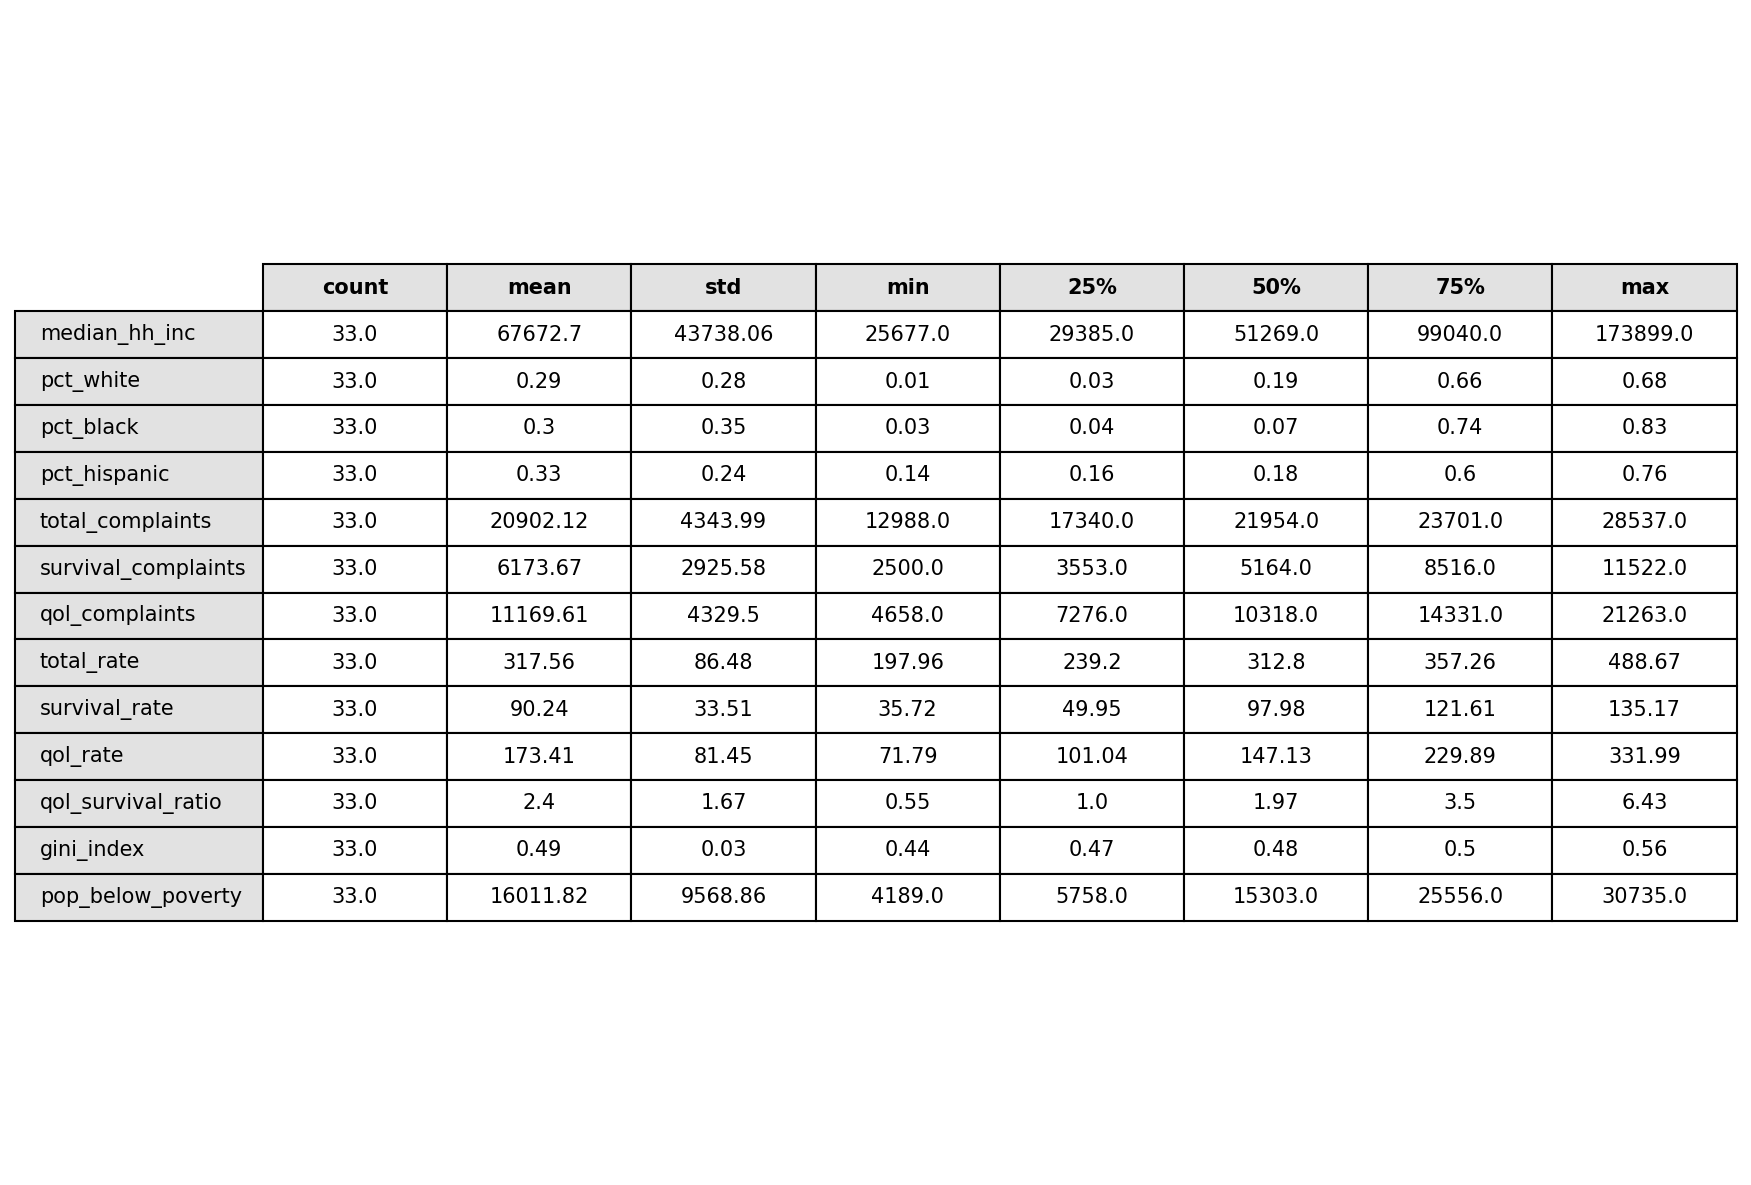

In [24]:

# quick summary stats for the main neighborhood variables

summary_vars = [
    'median_hh_inc', 'pct_white', 'pct_black', 'pct_hispanic',
    'total_complaints', 'survival_complaints', 'qol_complaints',
    'total_rate', 'survival_rate', 'qol_rate', 'qol_survival_ratio',
    'gini_index', 'pop_below_poverty'
]

print("\n── Overall summary ───────────────────────────────────────────────────")
print(df[summary_vars].describe().round(2).to_string())

print("\n── Summary BY ZIP ────────────────────────────────────────────────────")
print(df.groupby('ZIP')[summary_vars].mean().round(2).to_string())




# 1. Prep data (Transposed is usually best for reading long lists of variables)
stats_df = df[summary_vars].describe().round(2).T 

fig, ax = plt.subplots(figsize=(12, 8))
ax.axis('off')

# 2. Create the table
table = ax.table(
    cellText=stats_df.values,
    colLabels=stats_df.columns,
    rowLabels=stats_df.index,
    loc='center',
    cellLoc='center'
)

# 3. Apply custom styling to Headers and Index Column
for (row, col), cell in table.get_celld().items():
    # Shade and Bold Header Row (row 0)
    if row == 0:
        cell.set_facecolor('#e2e2e2')  # Light Gray
        cell.set_text_props(weight='bold')
        
    # Shade and Bold Index Column (col -1)
    if col == -1:
        cell.set_facecolor("#e2e2e2")  # Light Gray

# 4. Final Formatting
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

plt.tight_layout()
plt.savefig('tab01_summary_statistics.png', bbox_inches='tight', dpi=300)
plt.show()




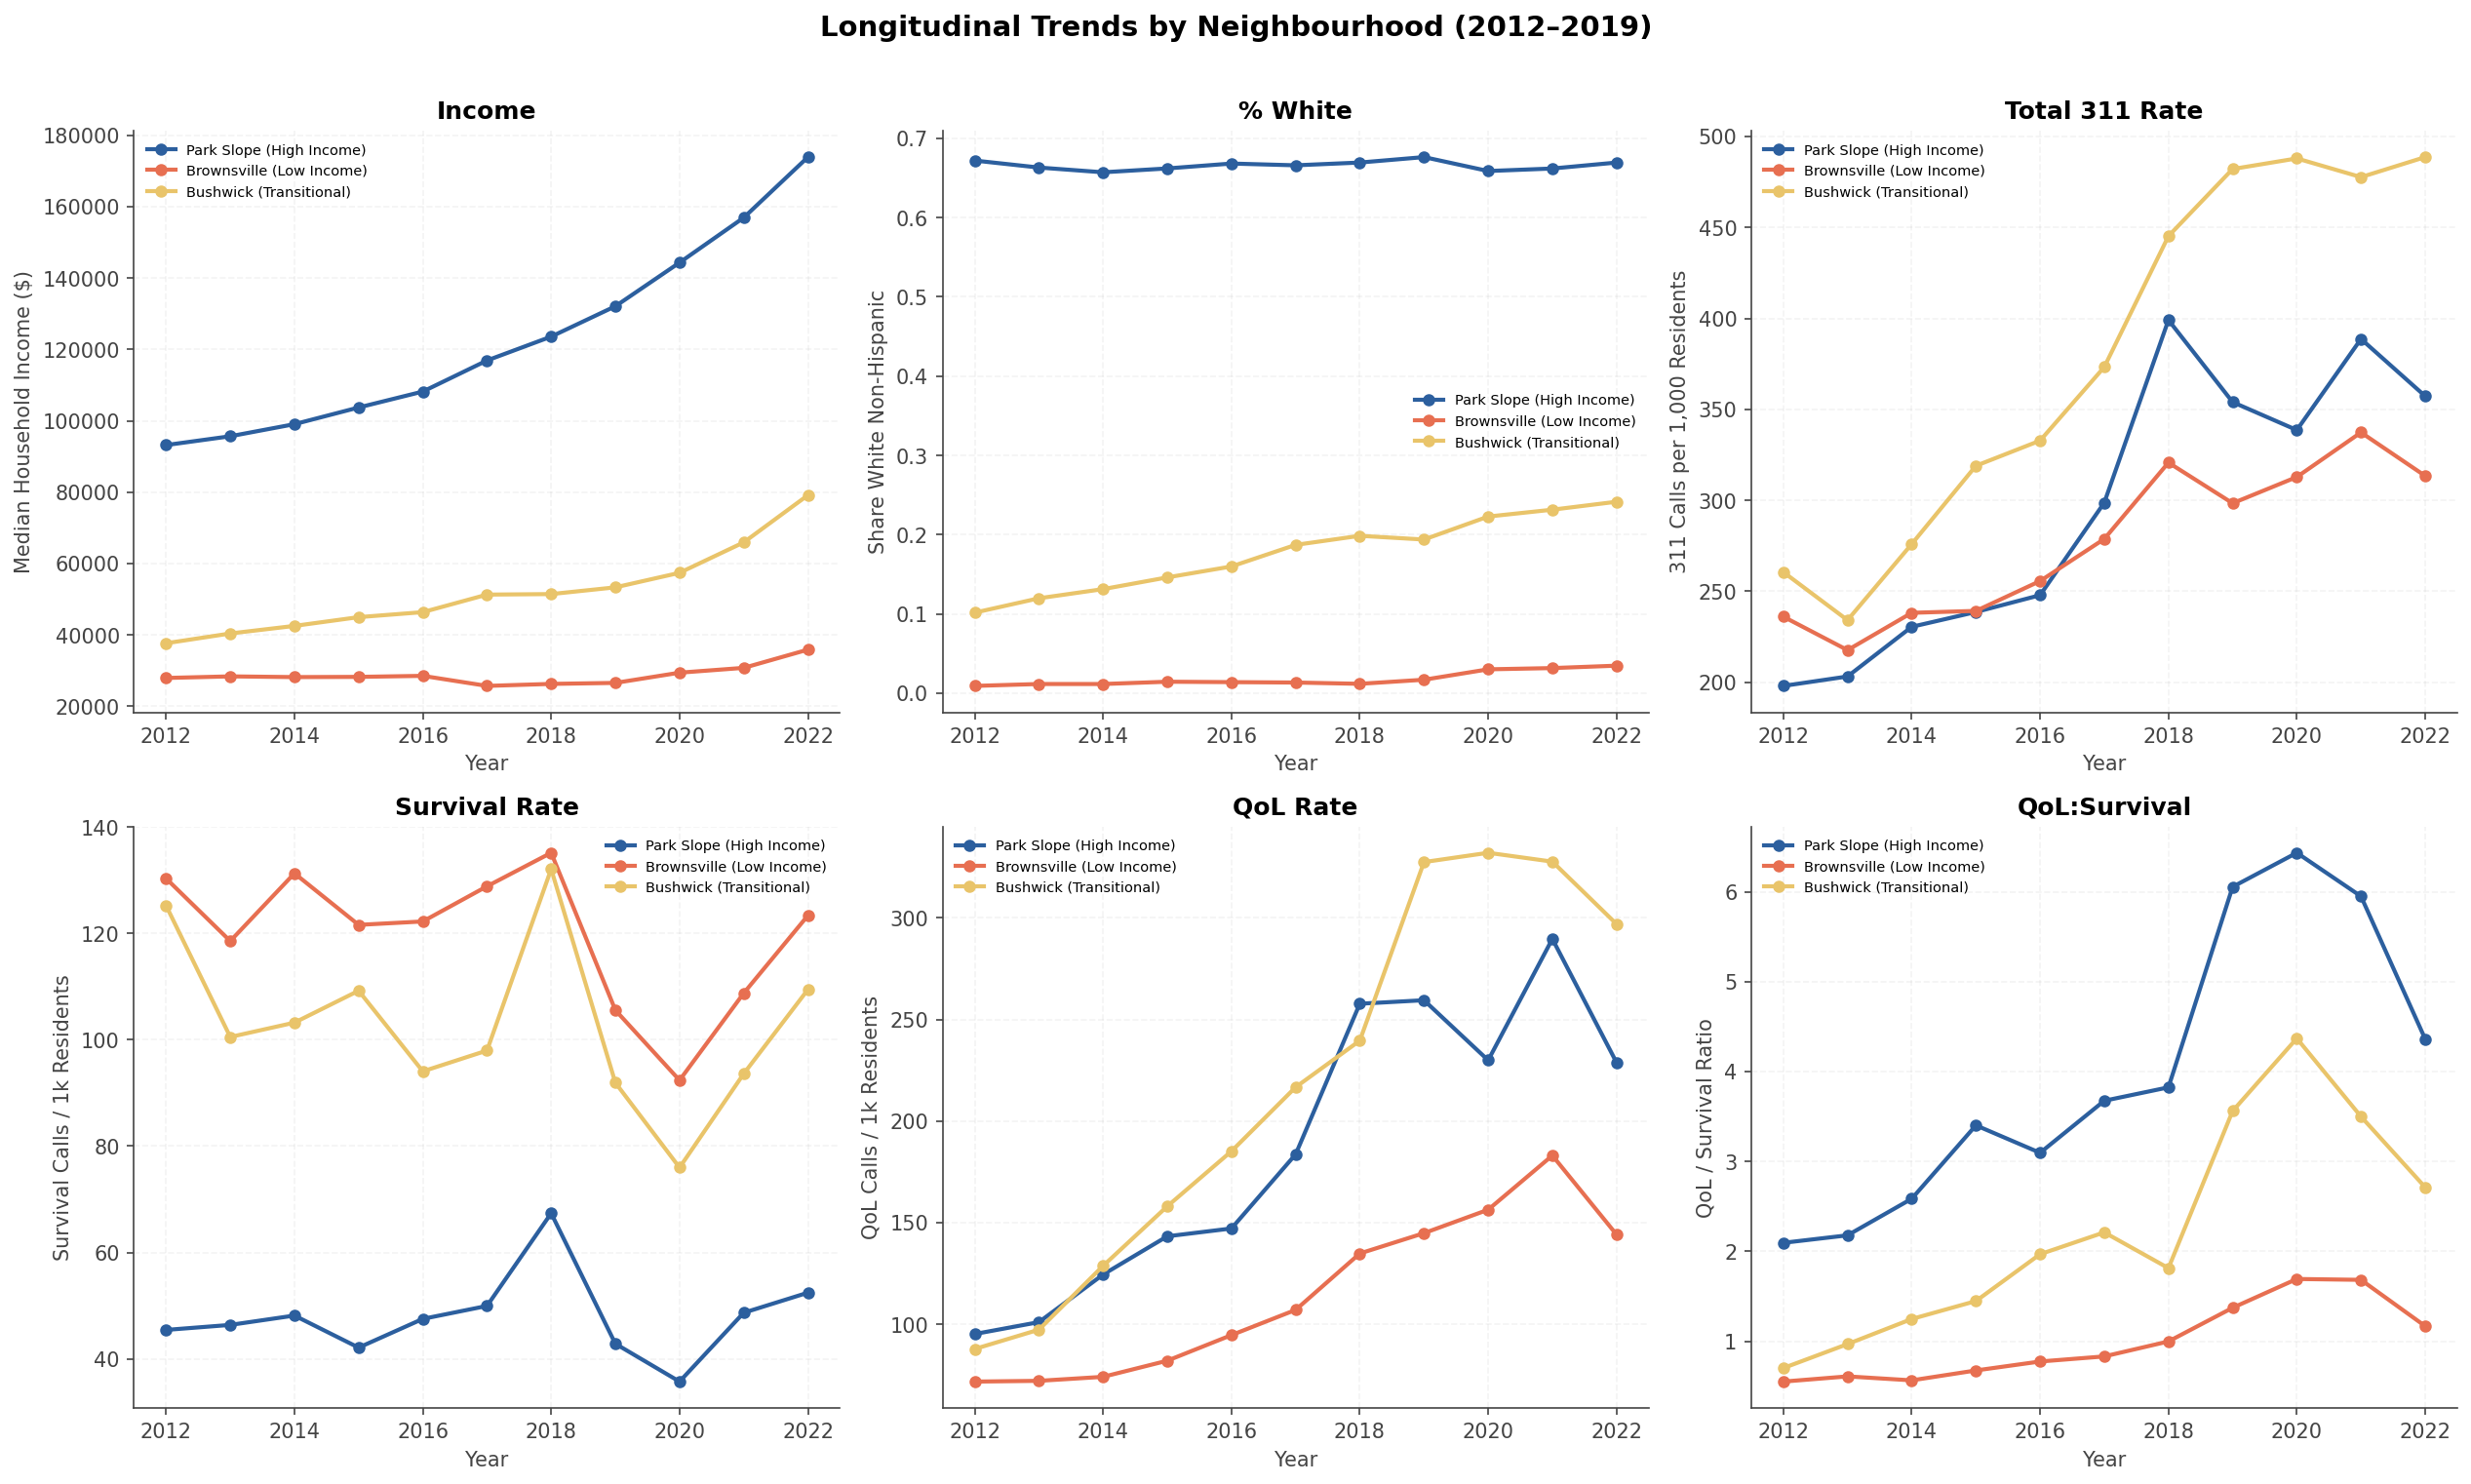

Saved → fig1_longitudinal_trends.png


In [7]:

# trends over time for selected zip codes

zips = ['11215', '11212', '11237']

fig, axes = plt.subplots(2, 3, figsize=(17, 10), sharey=False)
fig.suptitle('Longitudinal Trends by Neighbourhood (2012–2019)',
             fontsize=14, fontweight='bold', y=1.01)

metrics = [
    ('median_hh_inc',       'Median Household Income ($)',   'Income'),
    ('pct_white',           'Share White Non-Hispanic',      '% White'),
    ('total_rate',          '311 Calls per 1,000 Residents', 'Total 311 Rate'),
    ('survival_rate',       'Survival Calls / 1k Residents', 'Survival Rate'),
    ('qol_rate',            'QoL Calls / 1k Residents',      'QoL Rate'),
    ('qol_survival_ratio',  'QoL / Survival Ratio',          'QoL:Survival'),
]

for ax, (col, ylabel, title) in zip(axes.flatten(), metrics):
    for z in zips:
        sub = df[df['ZIP'] == z].sort_values('YEAR')
        ax.plot(sub['YEAR'], sub[col],
                marker='o', label=ZIP_LABELS[z],
                color=PALETTE[z], linewidth=2, markersize=5)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('fig1_longitudinal_trends.png', bbox_inches='tight')
plt.show()
print("Saved → fig1_longitudinal_trends.png")

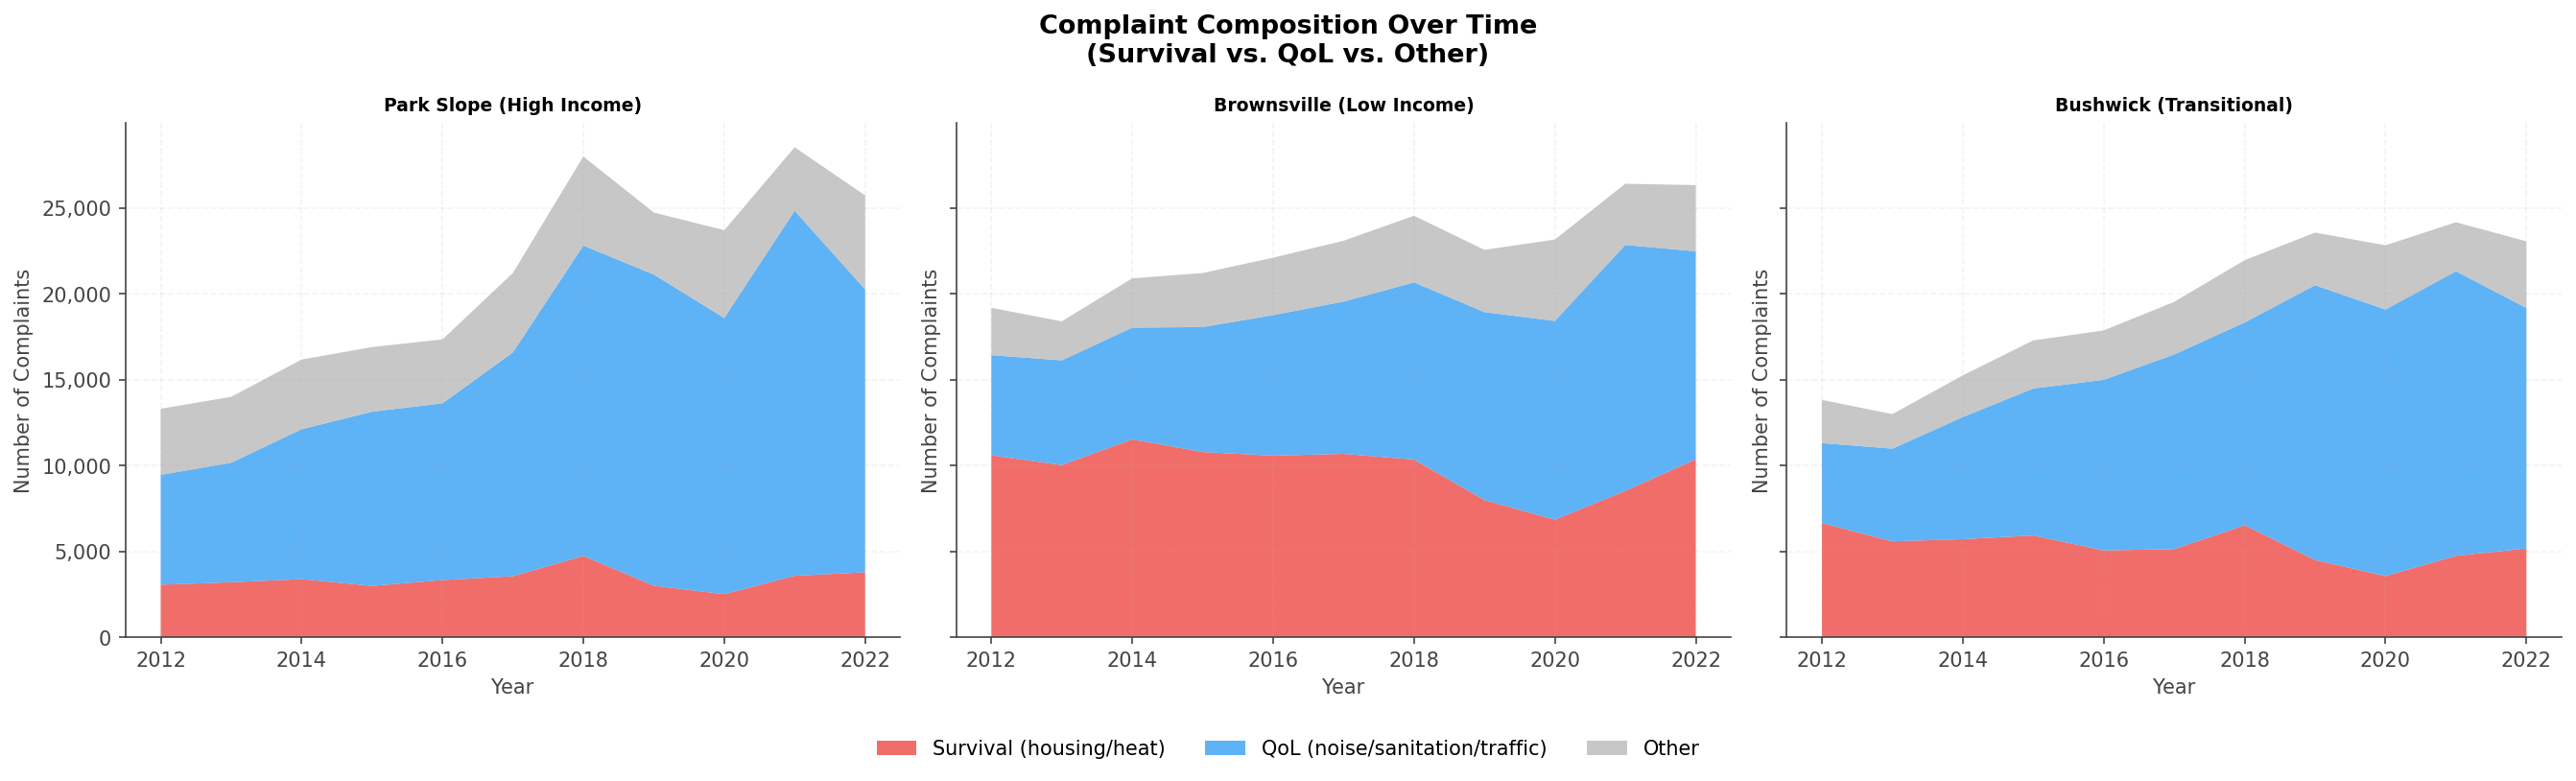

Saved → fig2_complaint_composition.png


In [8]:

# looking at how the mix of complaint types changes
#    Shows the "digital fingerprint" shift

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
fig.suptitle('Complaint Composition Over Time\n(Survival vs. QoL vs. Other)',
             fontsize=13, fontweight='bold')

other_cols = ['public_safety', 'parks_nature', 'finance_legal',
              'business_consumer', 'tech_infrastructure',
              'education', 'other_misc']

for ax, z in zip(axes, zips):
    sub = df[df['ZIP'] == z].sort_values('YEAR')
    other = sub[other_cols].sum(axis=1)

    ax.stackplot(
        sub['YEAR'],
        sub['survival_complaints'],
        sub['qol_complaints'],
        other,
        labels=['Survival (housing/heat)', 'QoL (noise/sanitation/traffic)', 'Other'],
        colors=['#EF5350', '#42A5F5', '#BDBDBD'],
        alpha=0.85
    )
    ax.set_title(ZIP_LABELS[z], fontweight='bold', fontsize=9)
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Complaints')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.08))
plt.tight_layout()
plt.savefig('fig2_complaint_composition.png', bbox_inches='tight')
plt.show()
print("Saved → fig2_complaint_composition.png")



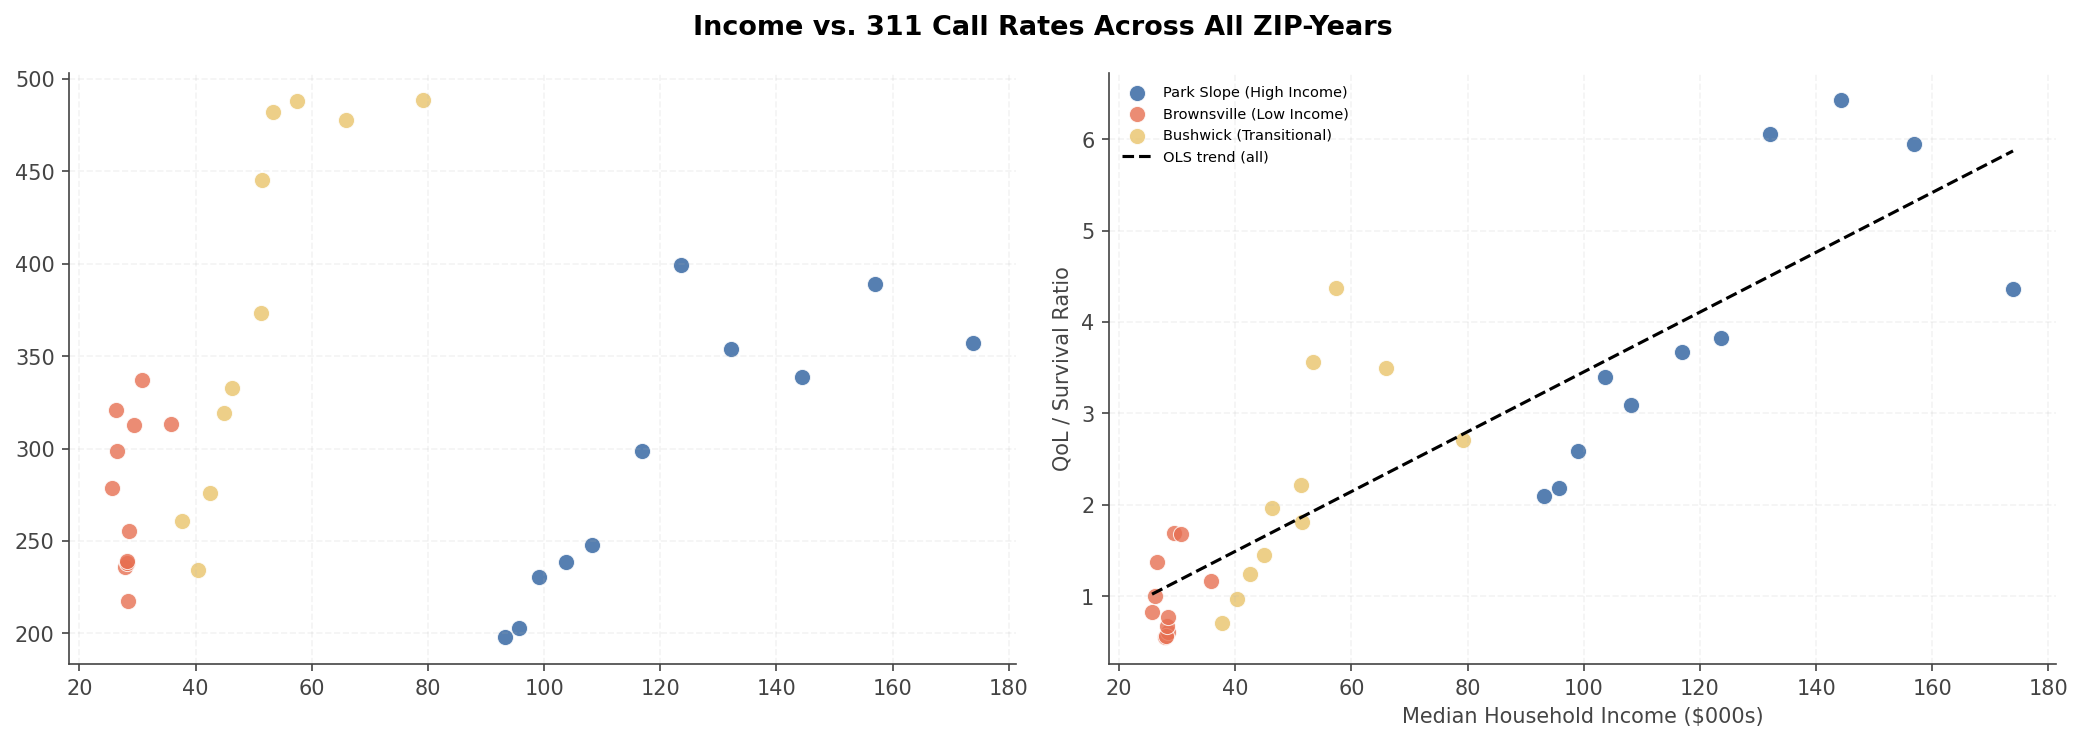

Saved → fig3_income_vs_complaints.png


In [9]:

# income vs complaint rates
#    Research Q1 – does income predict call volume?

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Income vs. 311 Call Rates Across All ZIP-Years',
             fontsize=13, fontweight='bold')

for ax, (y_col, y_label) in zip(axes, [
    ('total_rate',    'Total 311 Calls / 1k Residents'),
    ('qol_survival_ratio', 'QoL / Survival Ratio'),
]):
    for z in zips:
        sub = df[df['ZIP'] == z]
        ax.scatter(sub['median_hh_inc'] / 1000,
                   sub[y_col],
                   color=PALETTE[z],
                   label=ZIP_LABELS[z],
                   s=60, alpha=0.8, edgecolors='white', linewidth=0.5)

  # 1. Create a temporary 'clean' version of the data without NaNs
# This ensures x and y are the same length and have no holes
plot_data = df[['median_hh_inc', y_col]].dropna()

# 2. Use this clean data for the trend line
x_clean = plot_data['median_hh_inc'] / 1000
y_clean = plot_data[y_col]

# 3. Now polyfit will work perfectly
m, b = np.polyfit(x_clean, y_clean, 1)

# 4. Continue with your plotting...
xs = np.linspace(x_clean.min(), x_clean.max(), 100)
ax.plot(xs, m * xs + b, 'k--', linewidth=1.5, label='OLS trend (all)')
    
ax.set_xlabel('Median Household Income ($000s)')
ax.set_ylabel(y_label)
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('fig3_income_vs_complaints.png', bbox_inches='tight')
plt.show()
print("Saved → fig3_income_vs_complaints.png")

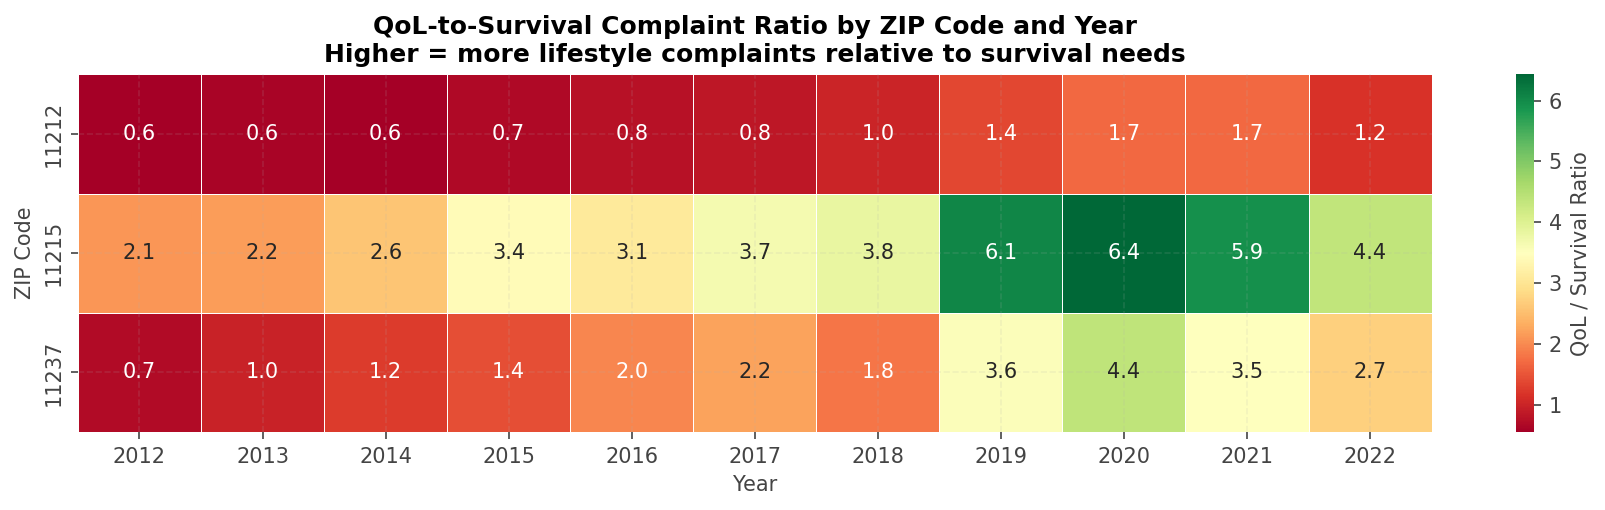

Saved → fig4_heatmap_qol_survival.png


In [10]:

# heatmap of QoL complaints relative to survival complaints
#    Visualises the gentrification "fingerprint"

pivot = df.pivot(index='ZIP', columns='YEAR', values='qol_survival_ratio')

fig, ax = plt.subplots(figsize=(12, 3.5))
sns.heatmap(
    pivot,
    annot=True, fmt='.1f',
    cmap='RdYlGn',          # red = survival-heavy, green = QoL-heavy
    linewidths=0.4,
    ax=ax,
    cbar_kws={'label': 'QoL / Survival Ratio'}
)
ax.set_title('QoL-to-Survival Complaint Ratio by ZIP Code and Year\n'
             'Higher = more lifestyle complaints relative to survival needs',
             fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('ZIP Code')
plt.tight_layout()
plt.savefig('fig4_heatmap_qol_survival.png', bbox_inches='tight')
plt.show()
print("Saved → fig4_heatmap_qol_survival.png")

In [41]:

# panel regressions with zip and year fixed effects


# Create ZIP and YEAR dummies for fixed effects
reg_df = df.copy()
reg_df['ZIP_fe']  = reg_df['ZIP'].astype('category')
reg_df['YEAR_fe'] = reg_df['YEAR'].astype('category')


m1 = smf.ols(
    'total_rate ~ inc_10k + pct_white + gini_index + C(ZIP_fe) + C(YEAR_fe)',
    data=reg_df
).fit(cov_type='HC3')


m2 = smf.ols(
    'qol_rate ~ inc_10k + pct_white + gini_index + C(ZIP_fe) + C(YEAR_fe)',
    data=reg_df
).fit(cov_type='HC3')


m3 = smf.ols(
    'survival_rate ~ inc_10k + pct_white + gini_index + C(ZIP_fe) + C(YEAR_fe)',
    data=reg_df
).fit(cov_type='HC3')


m4 = smf.ols(
    'qol_survival_ratio ~ inc_10k + pct_white + gini_index + C(ZIP_fe) + C(YEAR_fe)',
    data=reg_df
).fit(cov_type='HC3')


table = summary_col(
    [m1, m2, m3, m4],
    model_names=['Total Rate', 'QoL Rate', 'Survival Rate', 'QoL/Surv Ratio'],
    stars=True,
    info_dict={
        'N':    lambda m: f'{int(m.nobs)}',
        'R²':   lambda m: f'{m.rsquared:.3f}',
        'Adj R²': lambda m: f'{m.rsquared_adj:.3f}',
    },
    regressor_order=['inc_10k', 'pct_white', 'gini_index', 'Intercept']
)
print("\n── Panel Regression Results (ZIP + Year FE, HC3 SEs) ────────────────")
print(table)


── Panel Regression Results (ZIP + Year FE, HC3 SEs) ────────────────

                    Total Rate   QoL Rate  Survival Rate QoL/Surv Ratio
-----------------------------------------------------------------------
inc_10k            10.0074**   8.1457*     1.5612        0.2192        
                   (3.9670)    (4.5525)    (2.6147)      (0.1958)      
pct_white          750.0128*   664.0219*   -130.3209     -6.2242       
                   (384.7661)  (339.7572)  (177.9470)    (9.4326)      
gini_index         -537.2931   -591.1849   -137.7412     -24.1489      
                   (602.6444)  (534.2778)  (266.8582)    (17.2268)     
Intercept          457.9048    322.9579    197.3171      11.7277       
                   (305.6706)  (272.6450)  (140.2215)    (9.0317)      
C(ZIP_fe)[T.11215] -588.0330** -464.0790** -9.1906       3.7283        
                   (246.3982)  (226.9804)  (121.3261)    (6.8849)      
C(ZIP_fe)[T.11237] -69.3327*   -54.2600    -7.7178       0.3340 

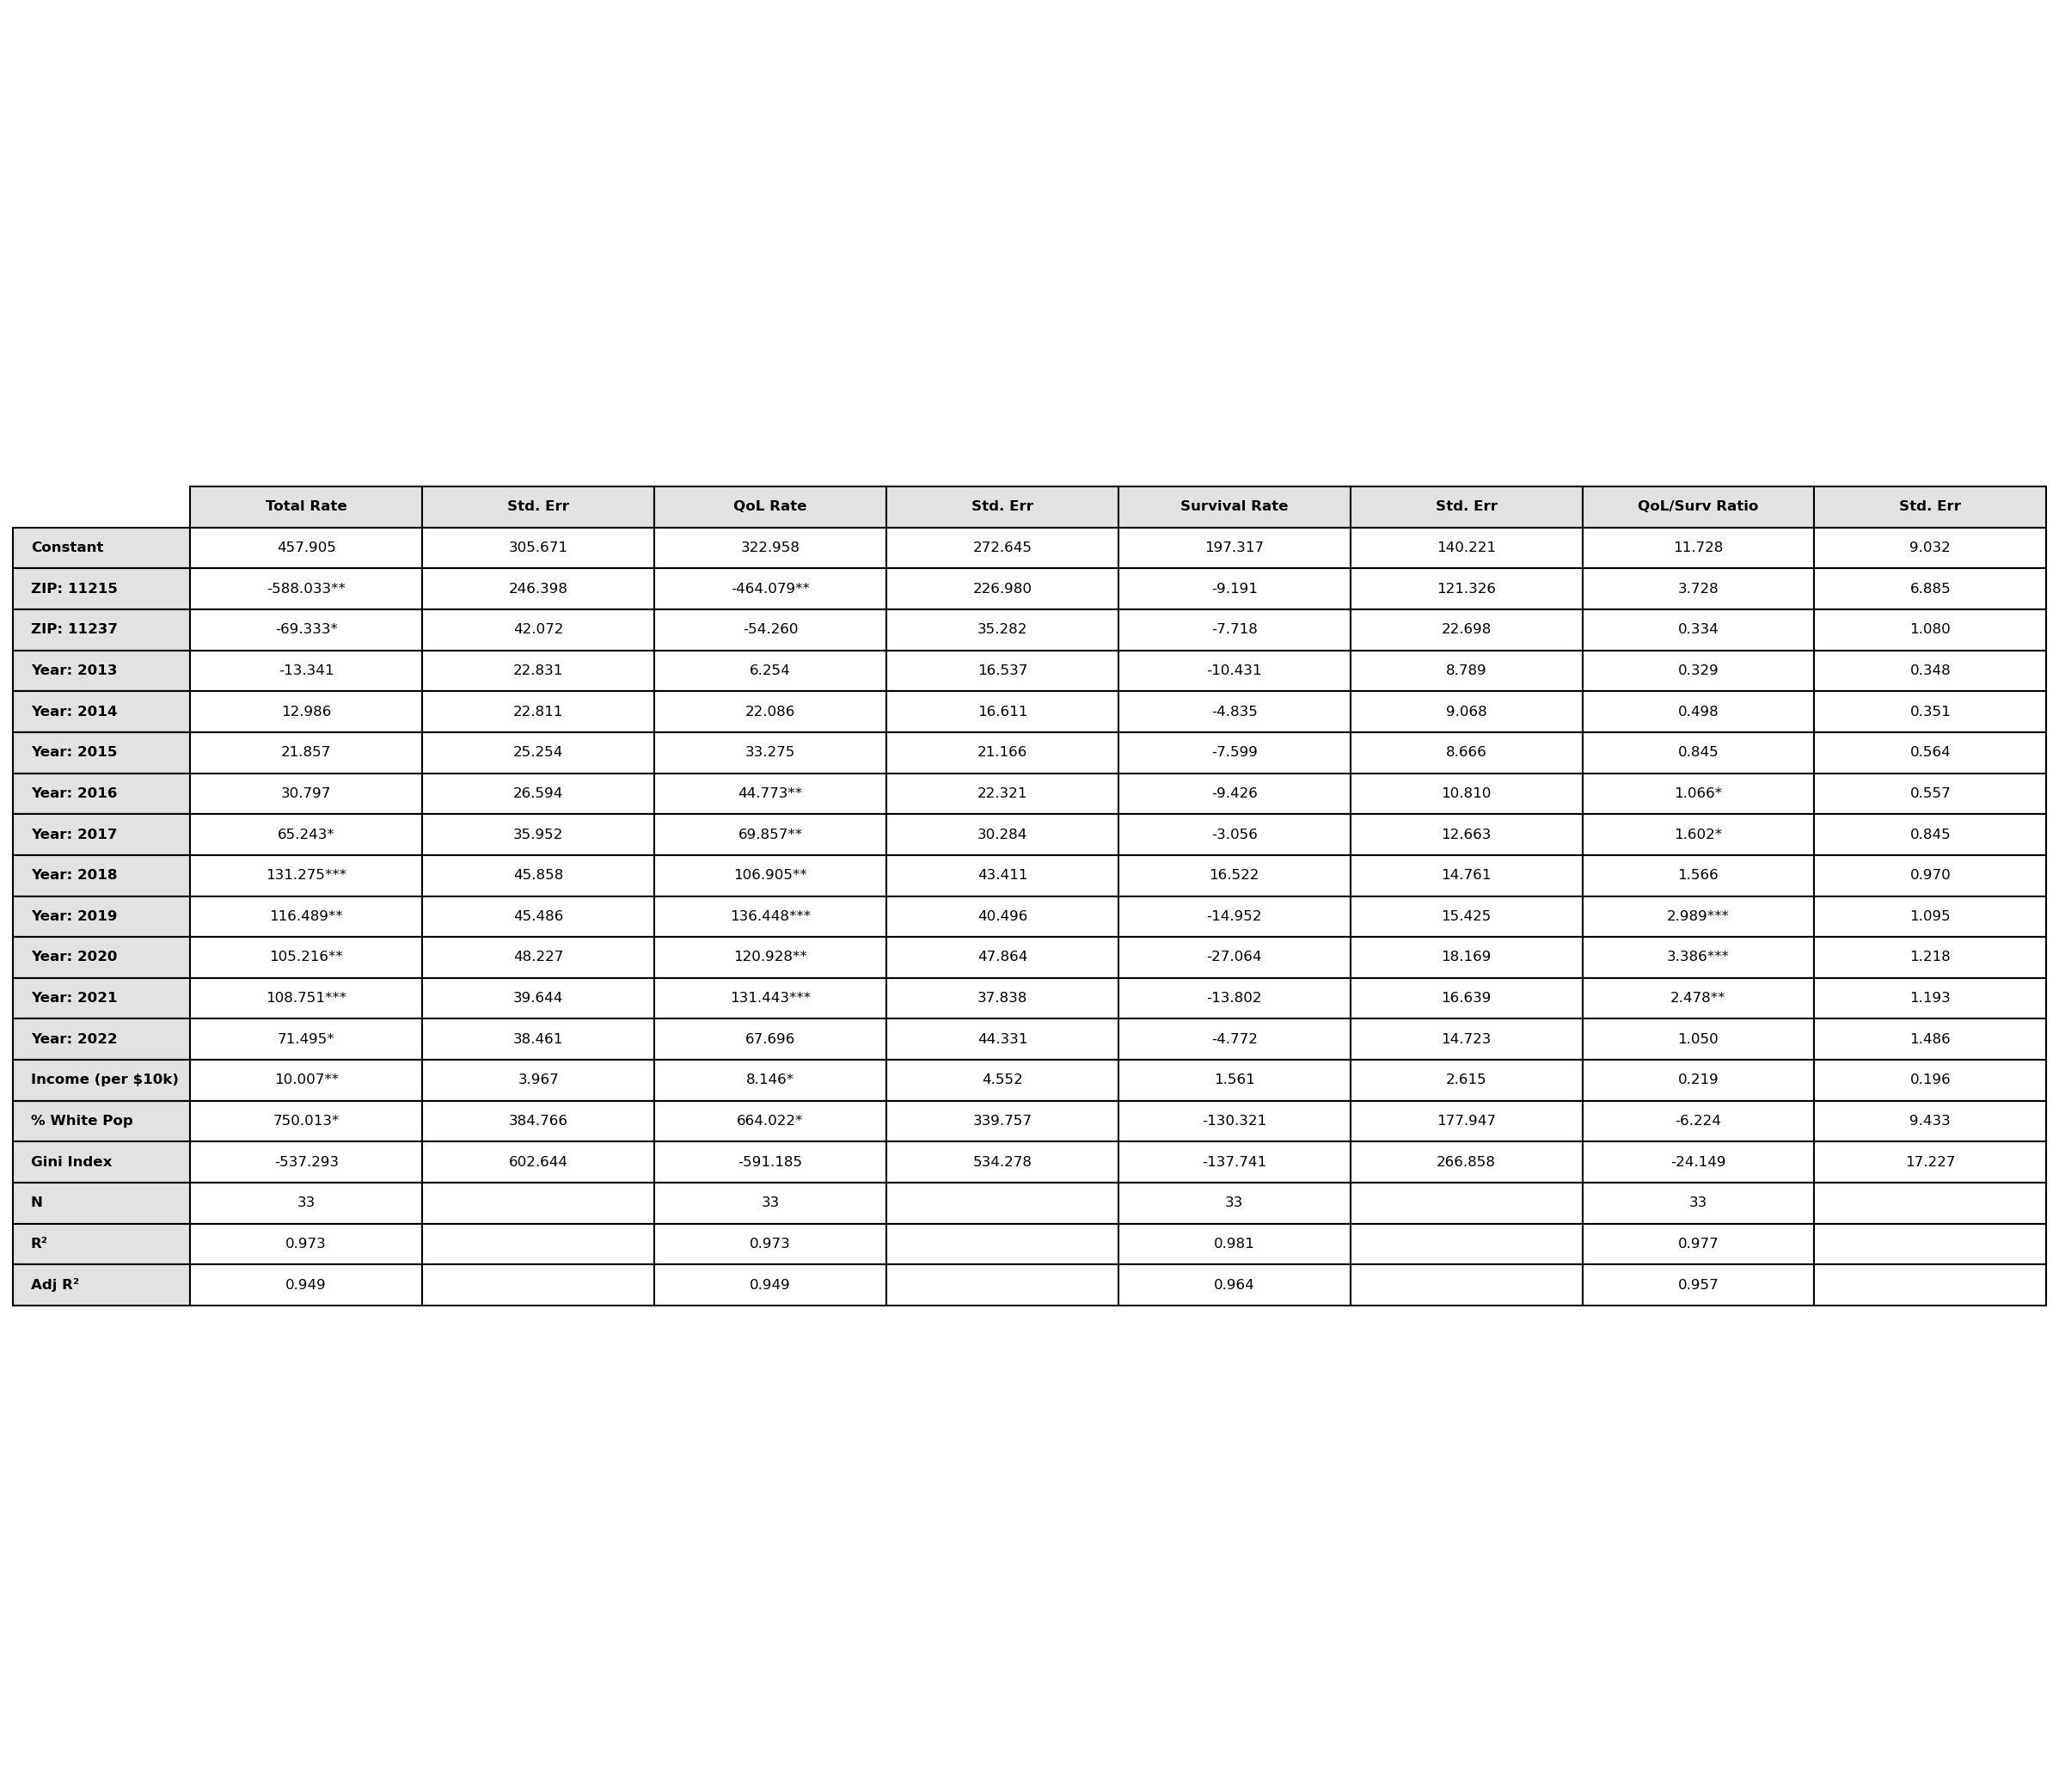

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Extract data and summary stats
models = [m1, m2, m3, m4]
model_names = ['Total Rate', 'QoL Rate', 'Survival Rate', 'QoL/Surv Ratio']

params = m1.params.index
data = []
index_names = []

# Process Coefficients
for p in params:
    row = []
    for m in models:
        coef = m.params.get(p, np.nan)
        p_val = m.pvalues.get(p, 1)
        stars = '***' if p_val < 0.01 else '**' if p_val < 0.05 else '*' if p_val < 0.1 else ''
        coef_str = f"{coef:.3f}{stars}"
        se = m.bse.get(p, np.nan)
        se_str = f"{se:.3f}" if not np.isnan(se) else ""
        row.extend([coef_str, se_str])
    data.append(row)
    
    idx = str(p)
    if 'C(ZIP_fe)' in idx: name = f'ZIP: {idx.split("[T.")[1].replace("]", "")}'
    elif 'C(YEAR_fe)' in idx: name = f'Year: {idx.split("[T.")[1].replace("]", "")}'
    elif 'inc_10k' in idx: name = 'Income (per $10k)'
    elif 'pct_white' in idx: name = '% White Pop'
    elif 'gini_index' in idx: name = 'Gini Index'
    elif 'Intercept' in idx: name = 'Constant'
    else: name = idx
    index_names.append(name)

# Process Summary Stats (N, R2, Adj R2)
summary_stats = {'N': lambda m: int(m.nobs), 'R²': lambda m: f"{m.rsquared:.3f}", 'Adj R²': lambda m: f"{m.rsquared_adj:.3f}"}
for label, func in summary_stats.items():
    row = []
    for m in models:
        val = func(m)
        row.extend([val, ""]) # No SE for summary stats
    data.append(row)
    index_names.append(label)

cols = []
for name in model_names:
    cols.extend([name, "Std. Err"])

final_df = pd.DataFrame(data, index=index_names, columns=cols)

# 2. Setup Figure
fig, ax = plt.subplots(figsize=(16, 14))
ax.axis('off')

# 3. Create the Table
tab = ax.table(
    cellText=final_df.values,
    colLabels=final_df.columns,
    rowLabels=final_df.index,
    loc='center',
    cellLoc='center'
)

# 4. Styling
for (row, col), cell in tab.get_celld().items():
    if row == 0:
        cell.set_facecolor('#e2e2e2')
        cell.set_text_props(weight='bold')
    if col == -1:
        cell.set_facecolor("#e2e2e2")
        cell.set_text_props(weight='bold')

# 5. Formatting
tab.auto_set_font_size(False)
tab.set_fontsize(8)
tab.scale(1.1, 1.5)

plt.tight_layout()
plt.savefig('tab02_panel_results_full.png', bbox_inches='tight', dpi=300)
plt.show()

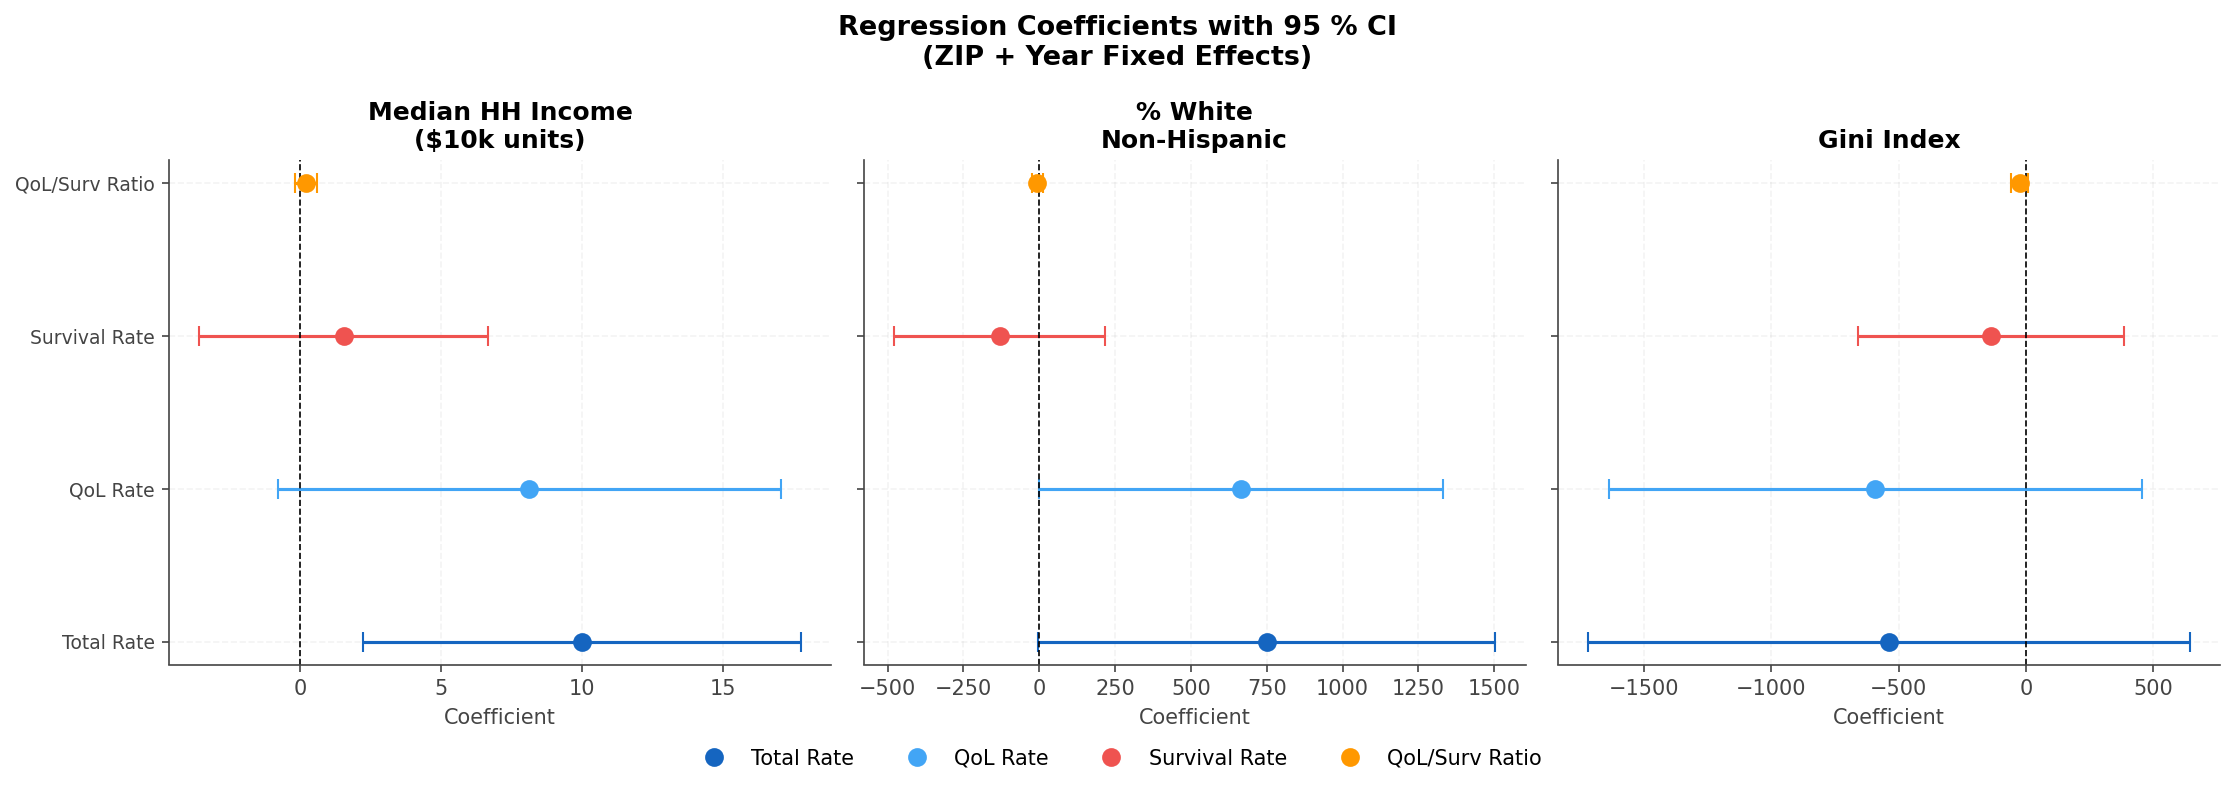

Saved → fig5_coef_plot.png


In [48]:

models   = {'Total Rate': m1, 'QoL Rate': m2,
            'Survival Rate': m3, 'QoL/Surv Ratio': m4}
key_vars = ['inc_10k', 'pct_white', 'gini_index']
var_labels = {
    'inc_10k':    'Median HH Income\n($10k units)',
    'pct_white':  '% White\nNon-Hispanic',
    'gini_index': 'Gini Index'
}

fig, axes = plt.subplots(1, len(key_vars), figsize=(15, 5), sharey=True)
fig.suptitle('Regression Coefficients with 95 % CI\n(ZIP + Year Fixed Effects)',
             fontsize=13, fontweight='bold')

colors_m = ['#1565C0', '#42A5F5', '#EF5350', '#FF9800']

for ax, var in zip(axes, key_vars):
    for i, (name, model) in enumerate(models.items()):
        coef = model.params.get(var, np.nan)
        ci   = model.conf_int().loc[var] if var in model.conf_int().index else [np.nan, np.nan]
        ax.errorbar(
            x=coef, y=i,
            xerr=[[coef - ci[0]], [ci[1] - coef]],
            fmt='o', color=colors_m[i], capsize=5,
            markersize=8, label=name
        )
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(var_labels[var], fontweight='bold')
    ax.set_xlabel('Coefficient')
    ax.set_yticks(range(len(models)))
    ax.set_yticklabels(list(models.keys()), fontsize=9)

handles = [plt.Line2D([0], [0], marker='o', color=c, markersize=8,
                       label=n, linestyle='')
           for c, n in zip(colors_m, models.keys())]
fig.legend(handles=handles, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.savefig('fig5_coef_plot.png', bbox_inches='tight')
plt.show()
print("Saved → fig5_coef_plot.png")

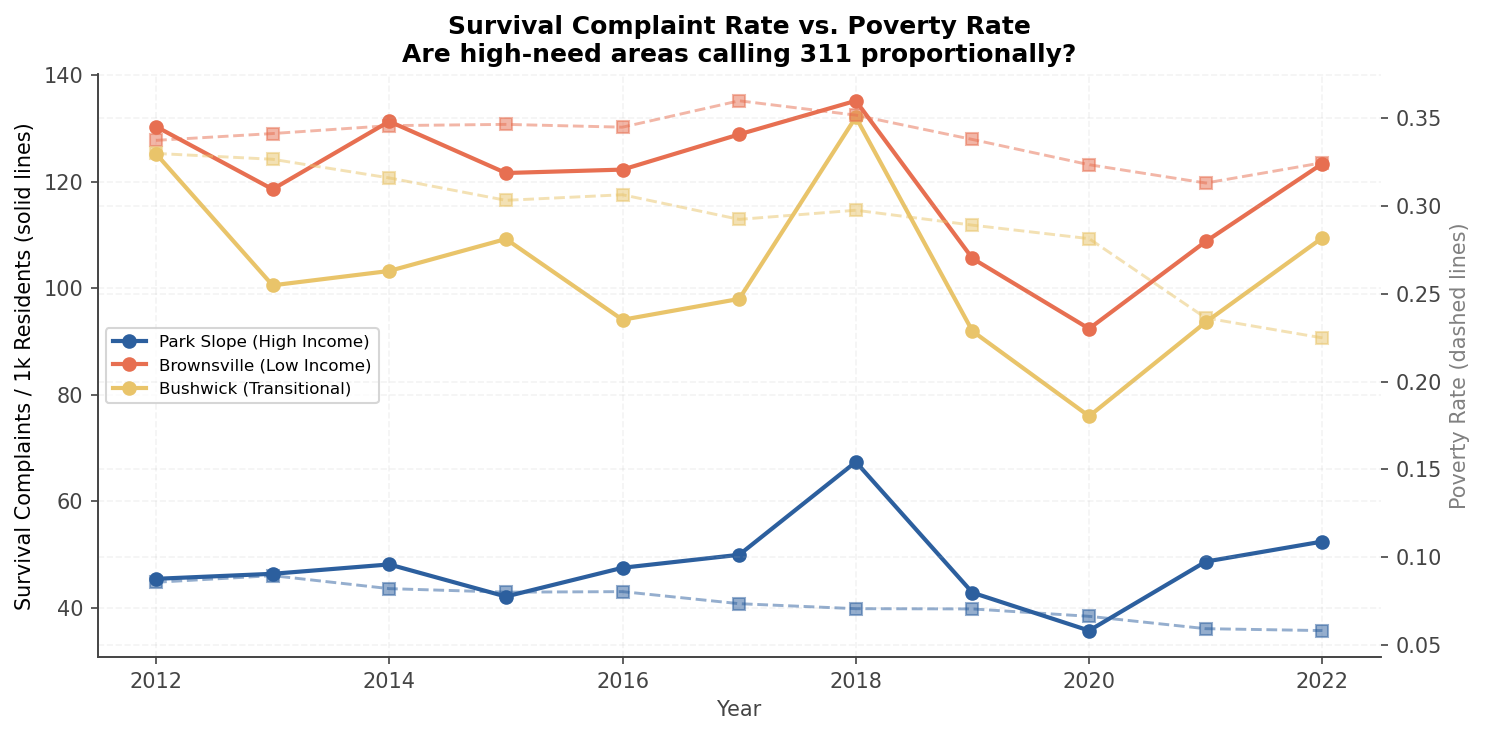

Saved → fig6_underreporting_gap.png


In [12]:

# possible underreporting check
#    Research Q3 – do low-income areas under-report
#    survival needs relative to their poverty share?

df['poverty_rate'] = df['pop_below_poverty'] / df['total_pop']

# Expected survival calls if proportional to poverty rate
# (simple benchmark: scale Park Slope's survival_rate by poverty share)
fig, ax = plt.subplots(figsize=(10, 5))

for z in zips:
    sub = df[df['ZIP'] == z].sort_values('YEAR')
    ax.plot(sub['YEAR'], sub['survival_rate'],
            marker='o', color=PALETTE[z],
            label=f'{ZIP_LABELS[z]}', linewidth=2)

ax2 = ax.twinx()
for z in zips:
    sub = df[df['ZIP'] == z].sort_values('YEAR')
    ax2.plot(sub['YEAR'], sub['poverty_rate'],
             marker='s', color=PALETTE[z],
             linestyle='--', linewidth=1.4, alpha=0.5)

ax.set_xlabel('Year')
ax.set_ylabel('Survival Complaints / 1k Residents (solid lines)', color='black')
ax2.set_ylabel('Poverty Rate (dashed lines)', color='grey')
ax.set_title('Survival Complaint Rate vs. Poverty Rate\n'
             'Are high-need areas calling 311 proportionally?',
             fontweight='bold')
# loc='upper left' sets the "anchor point" of the legend box to its top-left corner.
# bbox_to_anchor=(0.02, 0.8) moves that anchor to 2% from the left and 80% up the axis.
ax.legend(loc='center left', fontsize=8, frameon=True)
plt.tight_layout()
plt.savefig('fig6_underreporting_gap.png', bbox_inches='tight')
plt.show()
print("Saved → fig6_underreporting_gap.png")

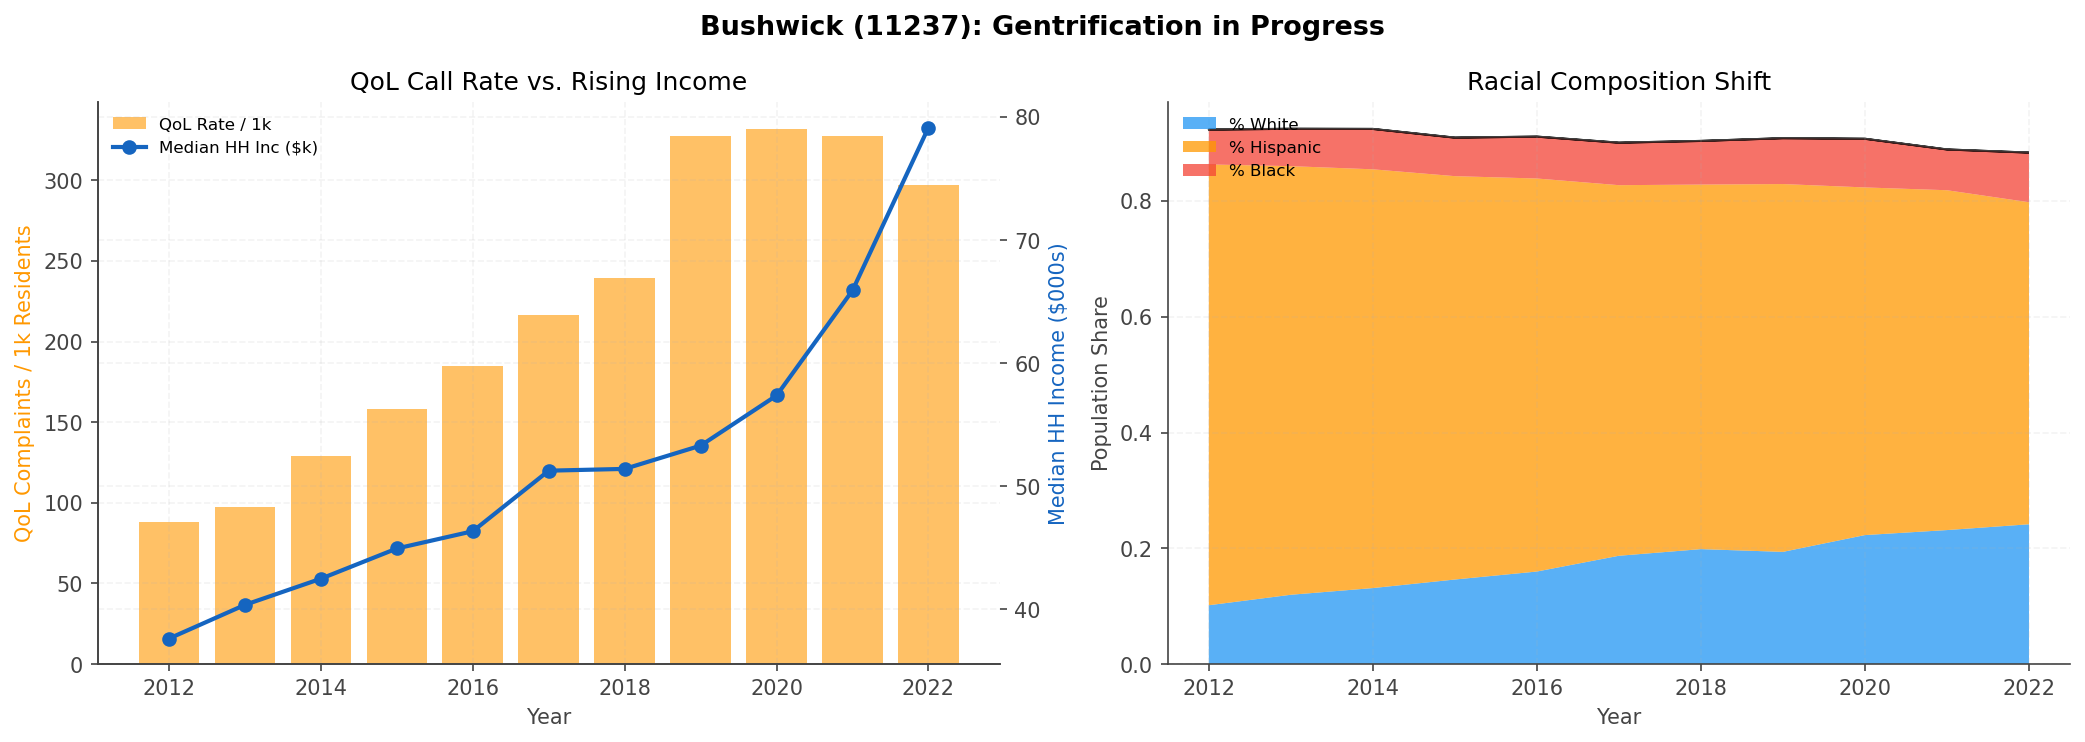

Saved → fig7_bushwick_gentrification.png


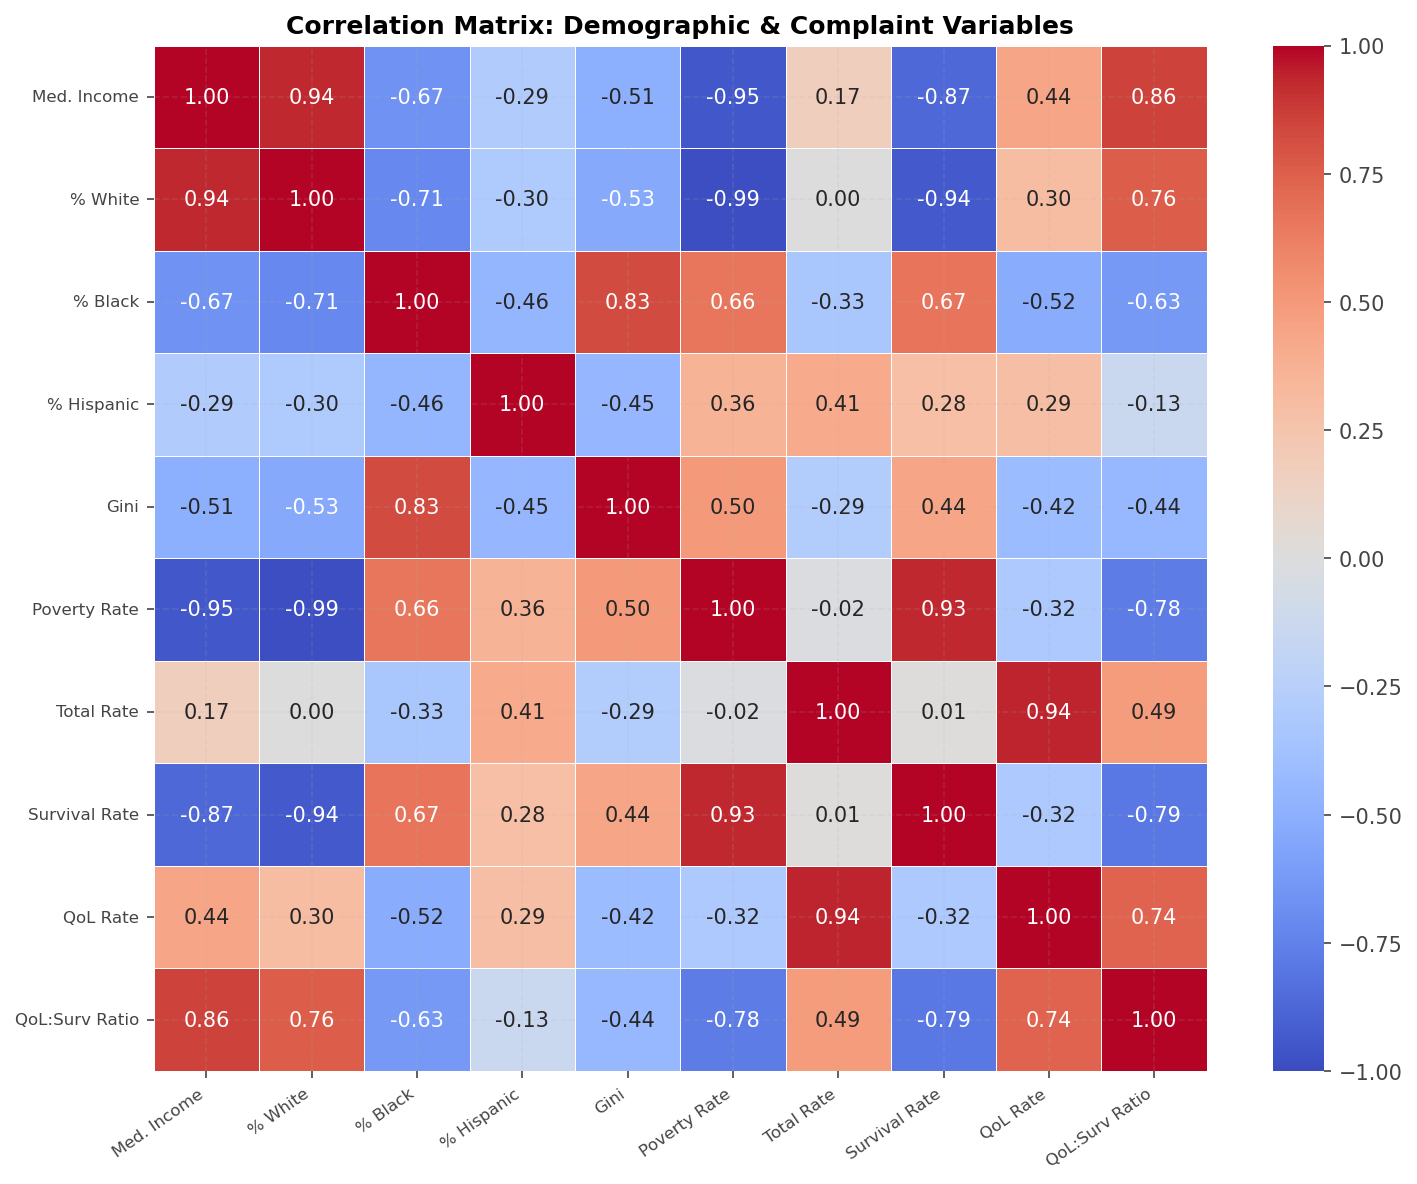

Saved → fig8_correlation_matrix.png


In [ ]:

# looking more closely at bushwick complaint patterns
#    Research Q2 – Bushwick as case study

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Bushwick (11237): Gentrification in Progress',
             fontsize=13, fontweight='bold')

bush = df[df['ZIP'] == '11237'].sort_values('YEAR')

# Left: income + QoL rate dual axis
ax = axes[0]
color_inc = '#1565C0'
color_qol = '#FF9800'
ax.bar(bush['YEAR'], bush['qol_rate'],
       color=color_qol, alpha=0.6, label='QoL Rate / 1k')
ax2_ = ax.twinx()
ax2_.plot(bush['YEAR'], bush['median_hh_inc'] / 1000,
          color=color_inc, marker='o', linewidth=2, label='Median HH Inc ($k)')
ax.set_xlabel('Year')
ax.set_ylabel('QoL Complaints / 1k Residents', color=color_qol)
ax2_.set_ylabel('Median HH Income ($000s)', color=color_inc)
ax.set_title('QoL Call Rate vs. Rising Income')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

# Right: racial composition over time
ax = axes[1]
ax.stackplot(
    bush['YEAR'],
    bush['pct_white'],
    bush['pct_hispanic'],
    bush['pct_black'],
    bush['pct_black'].apply(lambda _: 0),   # placeholder spacing
    labels=['% White', '% Hispanic', '% Black', ''],
    colors=['#2196F3', '#FF9800', '#F44336', 'none'],
    alpha=0.75
)
ax.set_xlabel('Year')
ax.set_ylabel('Population Share')
ax.set_title('Racial Composition Shift')
ax.legend(fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('fig7_bushwick_gentrification.png', bbox_inches='tight')
plt.show()
print("Saved → fig7_bushwick_gentrification.png")

In [ ]:


# correlation matrix for main variables

corr_vars = [
    'median_hh_inc', 'pct_white', 'pct_black', 'pct_hispanic',
    'gini_index', 'poverty_rate',
    'total_rate', 'survival_rate', 'qol_rate', 'qol_survival_ratio'
]
corr_labels = [
    'Med. Income', '% White', '% Black', '% Hispanic',
    'Gini', 'Poverty Rate',
    'Total Rate', 'Survival Rate', 'QoL Rate', 'QoL:Surv Ratio'
]

corr_matrix = df[corr_vars].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # upper triangle only
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    xticklabels=corr_labels,
    yticklabels=corr_labels,
    linewidths=0.4,
    ax=ax,
    vmin=-1, vmax=1
)
ax.set_title('Correlation Matrix: Demographic & Complaint Variables',
             fontweight='bold')
plt.xticks(rotation=35, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.savefig('fig8_correlation_matrix.png', bbox_inches='tight')
plt.show()
print("Saved → fig8_correlation_matrix.png")